In [1]:
import sys
sys.path.append('..')
from src.order_book import OrderBook, Side
from src.market_maker import MarketMaker
from src.simulator import Simulator

import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
def get_btc_trades_extended(n_batches=5):
    url = "https://api.exchange.coinbase.com/products/BTC-USD/trades"
    all_trades = []

    params = {"limit": 1000}
    for _ in range(n_batches):
        response = requests.get(url, params=params)
        batch = response.json()
        if not batch:
            break
        all_trades.extend(batch)
        oldest_id = min(t["trade_id"] for t in batch)
        params = {"limit": 1000, "after": oldest_id}

    df = pd.DataFrame(all_trades)
    df["price"] = pd.to_numeric(df["price"])
    df["size"] = pd.to_numeric(df["size"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.drop_duplicates(subset="trade_id")
    df = df.sort_values("time").reset_index(drop=True)
    df = df.set_index("time")
    return df

In [3]:
trades = get_btc_trades_extended()
print(f"Got {len(trades)} trades")

print(trades.dtypes)
trades.head()

Got 5000 trades
trade_id      int64
side         object
size        float64
price       float64
dtype: object


,trade_id,side,size,price
time,,,,
2026-05-20 19:53:40.015483+00:00,1021726606,buy,2.000000e-08,77580.01
2026-05-20 19:53:40.586650+00:00,1021726607,buy,9.000000e-08,77580.01
2026-05-20 19:53:41.189025+00:00,1021726608,buy,1.100000e-07,77580.01
2026-05-20 19:53:41.722608+00:00,1021726609,sell,2.164200e-04,77580.02
2026-05-20 19:53:42.918761+00:00,1021726610,sell,4.279000e-04,77579.97


In [4]:
book = OrderBook()
mm = MarketMaker(starting_wealth=100000, order_book=book)
sim = Simulator(mm=mm, book=book, df=trades, window=20)

mm.start_session()
sim.run()

In [5]:
print(f"Total buy trades: {len(trades[trades['side'] == 'buy'])}")
print(f"Total sell trades: {len(trades[trades['side'] == 'sell'])}")
print(f"Starting price: {trades['price'].iloc[0]}")
print(f"Ending price: {trades['price'].iloc[-1]}")
print(f"Price change: {trades['price'].iloc[-1] - trades['price'].iloc[0]:.2f}")

Total buy trades: 2962
Total sell trades: 2038
Starting price: 77580.01
Ending price: 77556.86
Price change: -23.15


In [6]:
results = sim.get_results()
results.tail(15)

,Mid_Price,Reservation_Price,Bid,Ask,Position,PnL,Spread
Time,,,,,,,
4985,77554.4730,77554.472994,77552.893664,77556.052324,0.773642,2.948095,3.158660
4986,77554.4735,77554.473494,77552.827068,77556.119920,0.773642,2.948481,3.292852
4987,77554.4740,77554.473994,77552.778536,77556.169452,0.773642,2.948868,3.390916
4988,77554.4745,77554.474495,77552.749439,77556.199550,0.773642,2.949255,3.450111
4989,77554.5095,77554.506311,77552.773241,77556.239381,0.773642,2.976332,3.466140
4990,77554.6290,77554.608303,77552.807873,77556.408733,0.773642,3.068783,3.600861
4991,77554.7490,77554.728320,77552.921340,77556.535299,0.773642,3.161620,3.613959
4992,77554.8690,77554.848303,77553.040567,77556.656039,0.773642,3.254457,3.615472
4993,77554.9885,77554.967821,77553.158676,77556.776966,0.773642,3.346907,3.618290


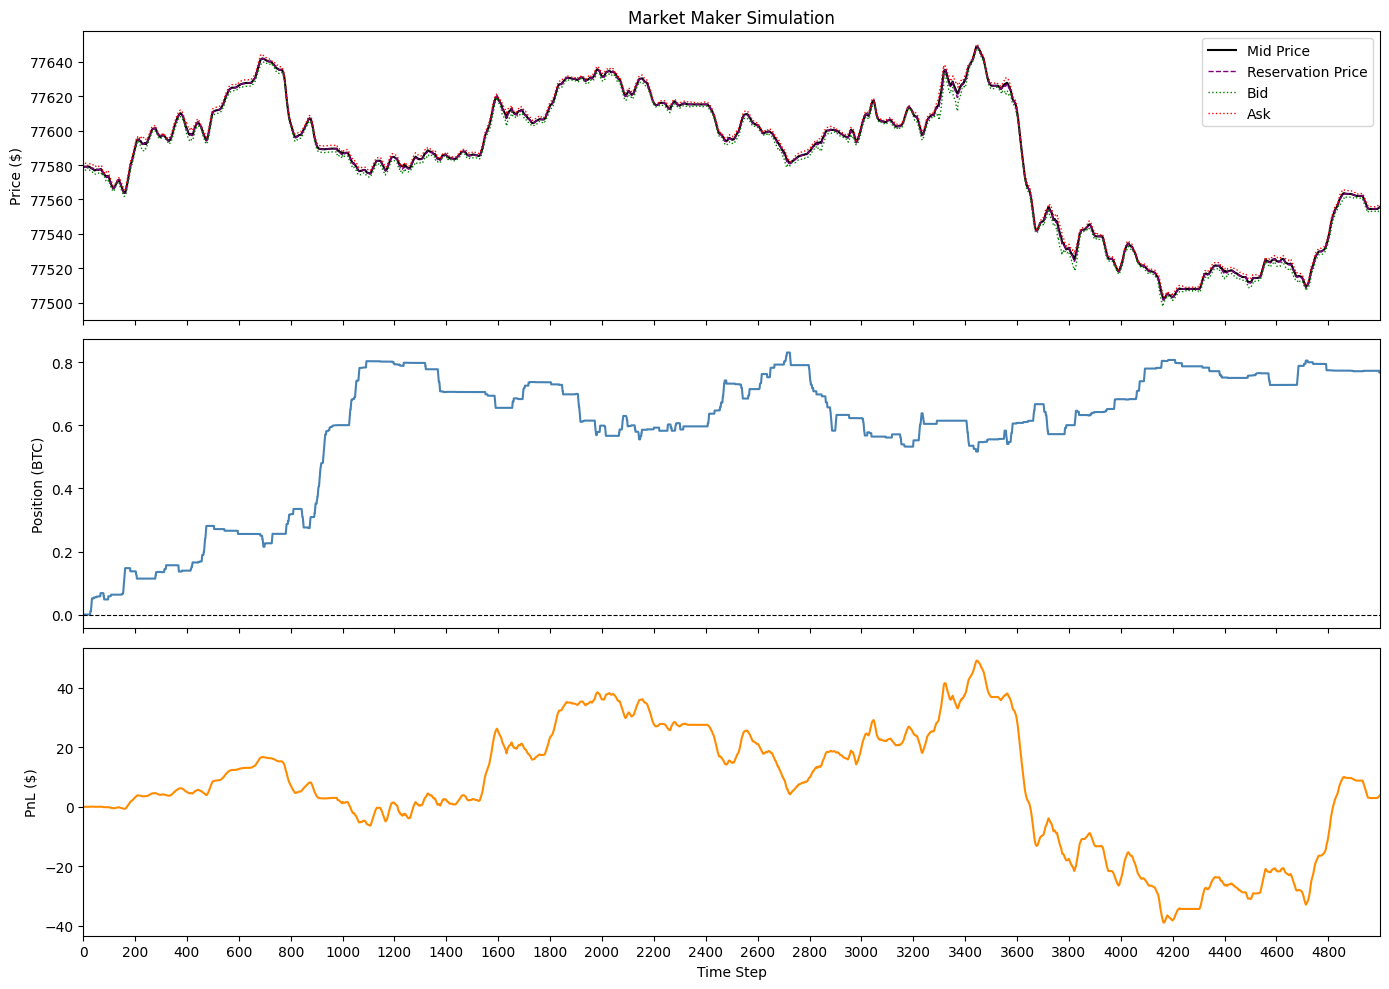

In [7]:
from matplotlib.ticker import MultipleLocator

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax1.plot(results.index, results['Mid_Price'], label='Mid Price', color='black', linewidth=1.5)
ax1.plot(results.index, results['Reservation_Price'], label='Reservation Price', color='purple', linewidth=1, linestyle='--')
ax1.plot(results.index, results['Bid'], label='Bid', color='green', linewidth=1, linestyle=':')
ax1.plot(results.index, results['Ask'], label='Ask', color='red', linewidth=1, linestyle=':')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper right')
ax1.set_title('Market Maker Simulation')
ax1.set_xlim(results.index[0], results.index[-1])

ax2.plot(results.index, results['Position'], color='steelblue', linewidth=1.5)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Position (BTC)')

ax3.plot(results.index, results['PnL'], color='darkorange', linewidth=1.5)
ax3.set_ylabel('PnL ($)')
ax3.set_xlabel('Time Step')
ax3.xaxis.set_major_locator(MultipleLocator(200))


plt.tight_layout()
plt.show()

Consistently ending with position around +0.2.

Market dominated by aggressive buyers and price rises over the sample.

Buyers keep hitting ask -> strategy sells
Gamma kicks in -> quotes rise
Ask and bid moves higher -> more sellers hit bids and less buyers hit ask

Dynamic gamma works and overcorrects, so strategy doesn't go infinitely short